
ρ(E→B) from realised graph  = +0.464
Derived ε                   = 0.036  →  theoretical ρ(C→B) = +0.464


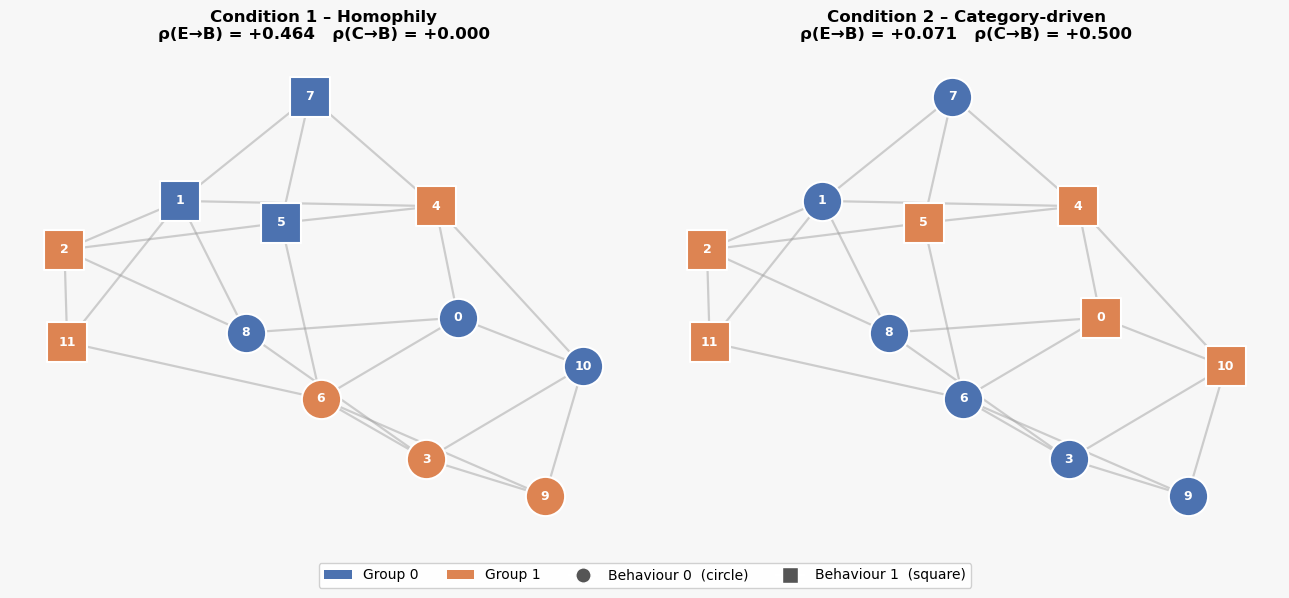


──────────────────────────────────────────────────────
             Correlation matching summary             
──────────────────────────────────────────────────────
  Theoretical target ρ(C→B) = +0.464  (ε = 0.036)
──────────────────────────────────────────────────────
                                   ρ(E→B)    ρ(C→B)
  Condition 1 – Homophily          +0.464    +0.000
  Condition 2 – Category           +0.071    +0.500
──────────────────────────────────────────────────────
  Realized ρ(C→B) may differ from target due to
  sampling variance at N=12. Increase N to reduce gap.

Figure saved.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── reproducibility ──────────────────────────────────────────────────────────
#np.random.seed(42)

# ── parameters ────────────────────────────────────────────────────────────────
N     = 12    # agents
M     = 2     # behaviours (0, 1)
K     = 2     # groups     (0, 1)
p_in  = 0.6  # edge prob  same latent behaviour  — keep ≤ p_out + 0.5
p_out = 0.2  # edge prob  different latent behaviour
# epsilon is derived from the realised graph so that ρ(C→B) ≈ ρ(E→B).
# For balanced binary (K=M=2): ρ(C→B) = (1−ε) − 0.5  →  ε = 0.5 − ρ(E→B).
# This requires ρ(E→B) ≤ 0.5; the script warns and clamps if not.


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — generate ONE base graph via homophily on latent behaviours
# ══════════════════════════════════════════════════════════════════════════════

# balanced latent behaviour assignment (N/M agents per behaviour)
latent_B = np.array([b for b in range(M) for _ in range(N // M)])
np.random.shuffle(latent_B)

# build adjacency via stochastic block model
A = np.zeros((N, N), dtype=int)
for i in range(N):
    for j in range(i + 1, N):
        prob = p_in if latent_B[i] == latent_B[j] else p_out
        if np.random.rand() < prob:
            A[i, j] = A[j, i] = 1

G_base = nx.from_numpy_array(A)

# fixed layout — identical across both panels so topology looks the same
pos = nx.spring_layout(G_base, seed=7)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — assign observable attributes per condition, with matched correlations
# ══════════════════════════════════════════════════════════════════════════════

# balanced group pool: exactly N/K agents per group — equated across conditions
agents_per_group = N // K
group_pool = np.array([g for g in range(K) for _ in range(agents_per_group)])

# ── Condition 1: Homophily ────────────────────────────────────────────────────
# observed behaviour = latent behaviour (network clusters by behaviour)
# group              = balanced shuffle, independent of behaviour and edges
B_cond1 = latent_B.copy()
C_cond1 = group_pool.copy()
np.random.shuffle(C_cond1)                     # C ⊥ B,  C ⊥ E

# ── Derive ε from the realised ρ(E→B) so that ρ(C→B) in Condition 2 matches ──
# ρ(E→B) = P(B_i = B_j | edge) − P(B_i = B_j | no edge)
same_edge, same_no_edge = [], []
for i in range(N):
    for j in range(i + 1, N):
        same = int(B_cond1[i] == B_cond1[j])
        (same_edge if A[i, j] == 1 else same_no_edge).append(same)
rho_EB = float(np.mean(same_edge) - np.mean(same_no_edge))

# Matching condition: ρ(C→B) = ρ(E→B)
# For balanced binary labels: ρ(C→B) = (1−ε) − 0.5  →  ε = 0.5 − ρ(E→B)
epsilon = float(np.clip(0.5 - rho_EB, 0.0, 0.5))
if rho_EB > 0.5:
    print(
        f"WARNING: ρ(E→B) = {rho_EB:.3f} exceeds matchable range [0, 0.5].\n"
        f"  ε clamped to 0 (perfect C→B mapping). "
        f"Lower p_in or raise p_out to fix."
    )

print(f"\nρ(E→B) from realised graph  = {rho_EB:+.3f}")
print(f"Derived ε                   = {epsilon:.3f}"
      f"  →  theoretical ρ(C→B) = {0.5 - epsilon:+.3f}")

# ── Condition 2: Category-driven ─────────────────────────────────────────────
# wipe all attributes; shuffle the same balanced group pool afresh;
# generate behaviour FROM reshuffled group labels using the derived ε
# assignment is independent of graph structure
C_cond2 = group_pool.copy()
np.random.shuffle(C_cond2)                     # fresh balanced shuffle

B_cond2 = np.zeros(N, dtype=int)
for i in range(N):
    k = C_cond2[i]
    # with prob (1−ε): behaviour matches group label  (signal)
    # with prob  ε   : behaviour flips               (noise)
    B_cond2[i] = k if np.random.rand() > epsilon else 1 - k


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — helper statistics
# ══════════════════════════════════════════════════════════════════════════════

def compute_rho_EB(A, B):
    """ρ(E→B): degree to which network proximity predicts shared behaviour."""
    se, sn = [], []
    for i in range(N):
        for j in range(i + 1, N):
            same = int(B[i] == B[j])
            (se if A[i, j] == 1 else sn).append(same)
    return float(np.mean(se) - np.mean(sn))

def compute_rho_CB(C, B):
    """ρ(C→B): degree to which group membership predicts behaviour."""
    return float(np.mean([B[i] == C[i] for i in range(N)]) - 0.5)

r_EB_c1 = compute_rho_EB(A, B_cond1)
r_CB_c1 = compute_rho_CB(C_cond1, B_cond1)
r_EB_c2 = compute_rho_EB(A, B_cond2)
r_CB_c2 = compute_rho_CB(C_cond2, B_cond2)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — visualise
# ══════════════════════════════════════════════════════════════════════════════

GROUP_COLORS  = {0: "#4C72B0",   # blue
                 1: "#DD8452"}   # orange
BEHAV_MARKERS = {0: "o",         # circle  = behaviour 0
                 1: "s"}         # square  = behaviour 1
NODE_SIZE  = 800
EDGE_ALPHA = 0.45


def draw_condition(ax, G, pos, C, B, title):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=11)
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color="#999999", alpha=EDGE_ALPHA, width=1.6
    )
    for b in range(M):
        for c in range(K):
            nodes = [i for i in range(N) if B[i] == b and C[i] == c]
            if not nodes:
                continue
            nx.draw_networkx_nodes(
                G, pos, ax=ax,
                nodelist=nodes,
                node_color=GROUP_COLORS[c],
                node_shape=BEHAV_MARKERS[b],
                node_size=NODE_SIZE,
                linewidths=1.5,
                edgecolors="white"
            )
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        labels={i: str(i) for i in range(N)},
        font_size=9, font_color="white", font_weight="bold"
    )
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor("#F7F7F7")

draw_condition(
    axes[0], G_base, pos, C_cond1, B_cond1,
    f"Condition 1 – Homophily\n"
    f"ρ(E→B) = {r_EB_c1:+.3f}   ρ(C→B) = {r_CB_c1:+.3f}"
)
draw_condition(
    axes[1], G_base, pos, C_cond2, B_cond2,
    f"Condition 2 – Category-driven\n"
    f"ρ(E→B) = {r_EB_c2:+.3f}   ρ(C→B) = {r_CB_c2:+.3f}"
)

# shared legend
legend_elements = [
    mpatches.Patch(facecolor=GROUP_COLORS[0], label="Group 0"),
    mpatches.Patch(facecolor=GROUP_COLORS[1], label="Group 1"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#555",
           markersize=11, label="Behaviour 0  (circle)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#555",
           markersize=11, label="Behaviour 1  (square)"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center", ncol=4,
    fontsize=10, framealpha=0.9,
    bbox_to_anchor=(0.5, 0.0)
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
#plt.savefig("/mnt/user-data/outputs/condition_graphs.png",
#            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ── correlation matching summary ──────────────────────────────────────────────
sep = "─" * 54
print(f"\n{sep}")
print(f"{'Correlation matching summary':^54}")
print(f"{sep}")
print(f"  Theoretical target ρ(C→B) = {0.5 - epsilon:+.3f}  (ε = {epsilon:.3f})")
print(f"{sep}")
print(f"  {'':30} {'ρ(E→B)':>8}  {'ρ(C→B)':>8}")
print(f"  {'Condition 1 – Homophily':30} {r_EB_c1:>+8.3f}  {r_CB_c1:>+8.3f}")
print(f"  {'Condition 2 – Category':30} {r_EB_c2:>+8.3f}  {r_CB_c2:>+8.3f}")
print(f"{sep}")
print(f"  Realized ρ(C→B) may differ from target due to")
print(f"  sampling variance at N={N}. Increase N to reduce gap.")
print(f"\nFigure saved.")